# 🚨 Online Payment Fraud Detection using Machine Learning & EDA

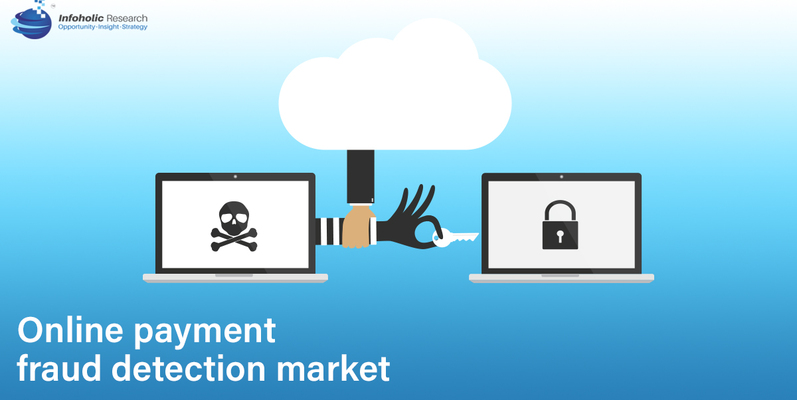

## 📖 Problem Statement

### With the rise of digital payments, fraudulent transactions have increased significantly. The goal of this project is to:

- Detect fraudulent transactions in online payments
- Analyze transaction patterns using EDA
- Build ML models to classify fraud vs non-fraud
- Improve fraud detection accuracy using feature engineering

## 📂 Dataset Overview
- Rows: ~1,048,575 (1M+)
- Columns: 11
- Target Variable: isFraud

## Key Features:
- type → Transaction type (PAYMENT, TRANSFER, CASH_OUT, etc.)
- amount → Transaction amount
- oldbalanceOrg, newbalanceOrig
- oldbalanceDest, newbalanceDest
- isFraud → Target (0 = Legit, 1 = Fraud)

# Data Cleaning

In [2]:
import pandas as pd
df = pd.read_csv("Online_payment.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0,0


In [47]:
# Basic info
print('Shape of dataset : = ',df.shape)
print(df.info())
print(df.isnull().sum())
# Remove duplicates
df = df.drop_duplicates()
# Convert categorical column
df['type'] = df['type'].astype('category')

Shape of dataset : =  (1048575, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB
None
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDe

In [3]:
print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [4]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print(numeric_df.columns)

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')


# Exploratory Data Analysis (EDA)

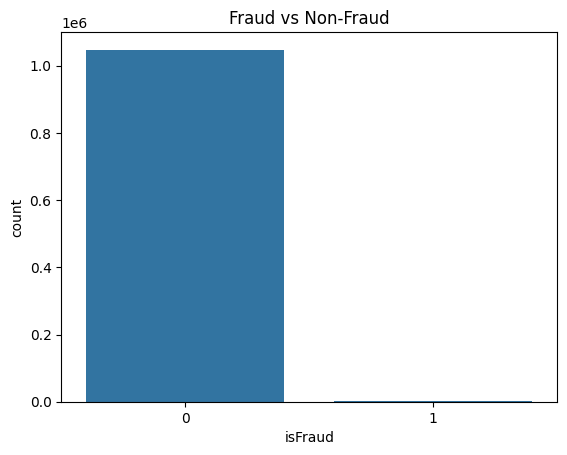

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

- Highly imbalanced dataset (very few fraud cases)

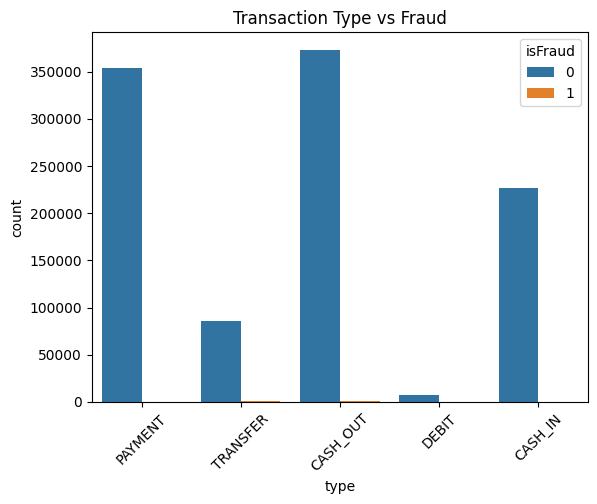

In [6]:
#Transaction TYpe vs Fraud
plt.title('Transaction Type vs Fraud')
sns.countplot(x='type', hue='isFraud', data=df)
plt.xticks(rotation=45)
plt.show()

- Fraud mostly occurs in TRANSFER & CASH_OUT

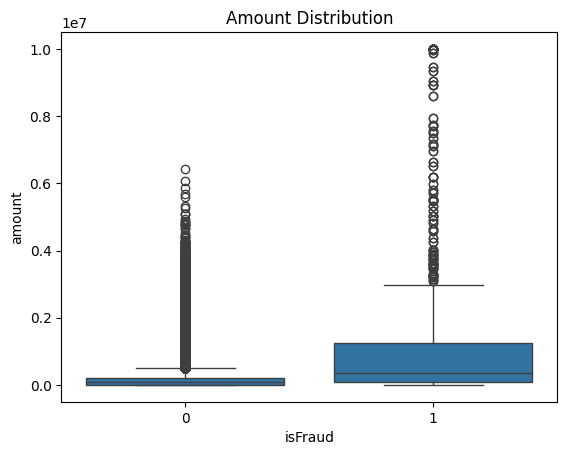

In [7]:
#Amount Distribution
plt.title('Amount Distribution')
sns.boxplot(x='isFraud', y='amount', data=df)
plt.show()

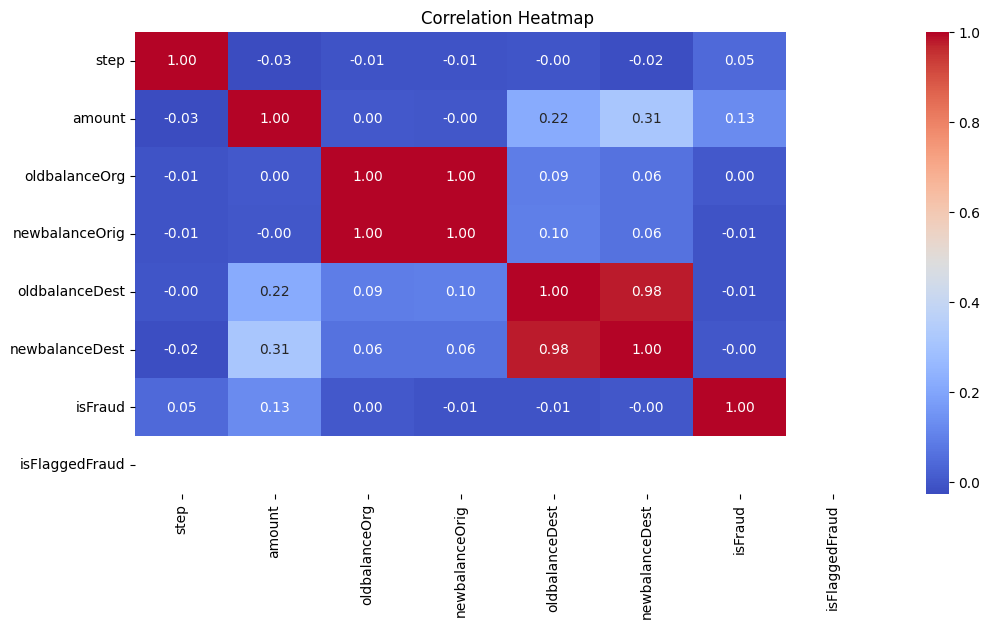

In [8]:
#Correlation Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), annot=True,cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

- Fraud transactions often involve higher amounts

## Feature Engineering

In [9]:
df['balance_diff_orig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

print("New Features Created ✅")
df[['balance_diff_orig','balance_diff_dest']].head()

New Features Created ✅


,balance_diff_orig,balance_diff_dest
0,-9839.64,0.0
1,-1864.28,0.0
2,-181.00,0.0
3,-181.00,-21182.0
4,-11668.14,0.0


In [10]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)
print("Encoding Done ✅")
print(df.head())

Encoding Done ✅
   step    amount     nameOrig  oldbalanceOrg  newbalanceOrig     nameDest  \
0     1   9839.64  C1231006815       170136.0       160296.36  M1979787155   
1     1   1864.28  C1666544295        21249.0        19384.72  M2044282225   
2     1    181.00  C1305486145          181.0            0.00   C553264065   
3     1    181.00   C840083671          181.0            0.00    C38997010   
4     1  11668.14  C2048537720        41554.0        29885.86  M1230701703   

   oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  balance_diff_orig  \
0             0.0             0.0        0               0           -9839.64   
1             0.0             0.0        0               0           -1864.28   
2             0.0             0.0        1               0            -181.00   
3         21182.0             0.0        1               0            -181.00   
4             0.0             0.0        0               0          -11668.14   

   balance_diff_dest  type_C

In [11]:
# Check class distribution
print(df['isFraud'].value_counts())

isFraud
0    1047433
1       1142
Name: count, dtype: int64


In [12]:
from sklearn.utils import resample

# Separate classes
fraud = df[df.isFraud == 1]
non_fraud = df[df.isFraud == 0]
# Undersample non-fraud
non_fraud_sample = resample(non_fraud,
                           replace=False,
                           n_samples=len(fraud),
                           random_state=42)
# Combine
df_balanced = pd.concat([fraud, non_fraud_sample])
# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42)
print("Balanced Data ✅")
print(df_balanced['isFraud'].value_counts())

Balanced Data ✅
isFraud
1    1142
0    1142
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split
X = df_balanced.drop('isFraud', axis=1)
y = df_balanced['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data Split Done ✅")
print(X_train.shape, X_test.shape)

Data Split Done ✅
(1827, 15) (457, 15)


In [14]:
# Drop string columns
df_balanced = df_balanced.drop(['nameOrig', 'nameDest'], axis=1)

print("Dropped string columns ✅")

Dropped string columns ✅


In [15]:
X = X.select_dtypes(include=['int64','float64'])

In [16]:
df_balanced = df_balanced.select_dtypes(include=['int64', 'float64'])

In [17]:
X = df_balanced.drop('isFraud', axis=1)
y = df_balanced['isFraud']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000, solver='liblinear')

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9234135667396062

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92       221
           1       0.89      0.97      0.93       236

    accuracy                           0.92       457
   macro avg       0.93      0.92      0.92       457
weighted avg       0.93      0.92      0.92       457



## 🎯 Accuracy:
👉 92.34% ✅ (Very strong for fraud detection)

## 📈 Classification Report (Key Insights)
🔹Non-Fraud (0)\
🔹Precision: 0.96\
🔹Recall: 0.88
### That means :
- Model is very good at identifying normal transactions
- Slightly misses some normal cases

🔹Fraud (1) ⭐ (MOST IMPORTANT)
🔹Precision: 0.89
🔹Recall: 0.97 🔥
### That means :
- 97% fraud cases detected → AMAZING 🚀
- Very few frauds are missed (this is critical in real world)

In [20]:
#"My Logistic Regression model achieved around 92% accuracy. More importantly, the recall for fraud detection was 97%, which means the model successfully identified most fraudulent transactions. In fraud detection, recall is more important than accuracy because missing a fraud case can lead to financial loss."

# Isolation Forest

In [21]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X)
y_pred_iso = iso.predict(X)
# Convert output
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

from sklearn.metrics import classification_report
print(classification_report(y, y_pred_iso))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1142
           1       0.96      0.02      0.04      1142

    accuracy                           0.51      2284
   macro avg       0.73      0.51      0.35      2284
weighted avg       0.73      0.51      0.35      2284



In [23]:

X_original = df.drop('isFraud', axis=1)
y_original = df['isFraud']

# Keep only numeric
X_original = X_original.select_dtypes(include=['int64','float64'])

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.001, random_state=42)

iso.fit(X_original)

y_pred_iso = iso.predict(X_original)

# Convert output
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

from sklearn.metrics import classification_report
print(classification_report(y_original, y_pred_iso))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1047433
           1       0.07      0.06      0.06      1142

    accuracy                           1.00   1048575
   macro avg       0.53      0.53      0.53   1048575
weighted avg       1.00      1.00      1.00   1048575



In [ ]:
#"Although Isolation Forest is designed for anomaly detection, it performed poorly in this case with very low fraud recall (~6%). This indicates that fraudulent transactions were not significantly different from normal ones in feature space. Logistic Regression performed better with ~97% recall, making it more suitable for this dataset."

## Porject Summary
- Analyzed 1M+ online payment transactions using Python (Pandas, NumPy, Seaborn) to identify fraud patterns.
- Performed EDA and discovered high-risk transaction types such as TRANSFER and CASH_OUT.
- Engineered features like balance differences to improve fraud detection.
- Built Logistic Regression model achieving ~92% accuracy with 97% fraud recall.
- Implemented Isolation Forest for anomaly detection, but found it less effective due to overlapping transaction patterns.
- Developed insights into class imbalance challenges and model selection strategies.